# Data correlation using principal components

In [ ]:
import numpy as np
import os
import pandas as pd
from datetime import datetime
import scipy.signal
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from sklearn.decomposition import PCA
from sklearn import preprocessing
from scipy import signal
import statistics

## Read and Fuse Data

In [2]:
#USING MPUA DATA ONLY (no proper result since different axis)

n = input('Which MPU dataset would you like to look at?')
df = pd.read_csv('CSV/Vibration_MPUA_{}.csv'.format(n))

df = df.drop(columns='Timestamp (float)').set_index('Date and Timestamp (string)')

KeyboardInterrupt: Interrupted by user

In [10]:
# USING Raw MPU and ADXL DATA (including median filtering and adjustment of adxl)
n = input('Which MPU/ADXL dataset would you like to look at?')
#dfa = pd.read_csv('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_MPUA_{}.csv'.format(n))
#dfg = pd.read_csv('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_ADXL_{}.csv'.format(n))
dfa = pd.read_csv('CSV/Vibration_MPUA_{}.csv'.format(n))
dfg = pd.read_csv('CSV/Vibration_ADXL_{}.csv'.format(n))
#Fusing MPU files together (gyro and acc)
x=len(dfa)
y=len(dfg)
print(x,y)
if y > x:
    dfg.drop(dfg.tail(abs(x-y)).index,inplace=True) # drop last n rows
if x > y:
    dfa.drop(dfa.tail(abs(x-y)).index,inplace=True) # drop last n rows
x=len(dfa)
y=len(dfg)
print(x,y)
dfa['X-Acc ADXL [g]']=dfg['X-Acc ADXL [g]']
dfa['Y-Acc ADXL [g]']=dfg['Y-Acc ADXL [g]']
dfa['Z-Acc ADXL [g]']=dfg['Z-Acc ADXL [g]']
df=dfa

a = -df['X-Acc ADXL [g]']
b = df['Y-Acc ADXL [g]']
c = df['Z-Acc ADXL [g]']
df['X-Acc ADXL [g]'] = b
df['Y-Acc ADXL [g]'] = c
df['Z-Acc ADXL [g]'] = a
kernel_size = 3
df['Z-Acc ADXL [g]'] = signal.medfilt(df['Z-Acc ADXL [g]'], kernel_size)
df['Y-Acc ADXL [g]'] = signal.medfilt(df['Y-Acc ADXL [g]'], kernel_size)
df['X-Acc ADXL [g]'] = signal.medfilt(df['X-Acc ADXL [g]'], kernel_size)

#Using timestamp as index
df = df.drop(columns=['Date and Timestamp (string)']).set_index('Timestamp (float)')
df

Which MPU/ADXL dataset would you like to look at?4
1782 1785
1782 1782


,X-Acc MPU [g],Y-Acc MPU [g],Z-Acc MPU [g],X-Acc ADXL [g],Y-Acc ADXL [g],Z-Acc ADXL [g]
Timestamp (float),,,,,,
1.652776e+09,-0.4407,-0.1292,-0.8108,-0.364,-0.108,-0.920
1.652776e+09,-0.4189,-0.1292,-0.8081,-0.364,-0.116,-0.932
1.652776e+09,-0.4189,-0.2324,-0.7903,-0.516,-0.184,-0.932
1.652776e+09,-0.2886,-0.2324,-0.9778,-0.516,-0.184,-1.036
1.652776e+09,-0.2886,0.0427,-0.9834,-0.516,-0.128,-1.056
...,...,...,...,...,...,...
1.652776e+09,-0.3203,-0.1301,-0.9260,-0.376,-0.088,-1.024
1.652776e+09,-0.3203,-0.1140,-0.9314,-0.376,-0.088,-1.024
1.652776e+09,-0.3345,-0.1140,-0.9314,-0.376,-0.076,-1.012


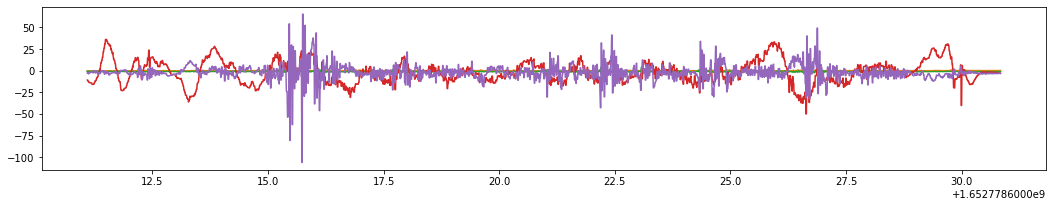

In [17]:
plt.figure(figsize=(18, 3))
plt.plot(df)

## Perform PCA to find Principal Components

In [18]:
# Center and scale the data (variance = 1, mean = 0)
scaled_df = preprocessing.scale(df.T)
print (scaled_df)

[[ 0.62104121  0.58333231  0.53891807 ...  0.74705311  0.74705311
   0.79051012]
 [ 0.69814183  0.74575599  0.66553086 ...  1.29551684  1.29551684
   1.19364448]
 [ 0.57549782  0.56698937  0.52488836 ...  0.26945679  0.26945679
   0.38193403]
 [-1.94754048 -1.94416614 -1.98176857 ... -1.06060121 -1.06060121
  -1.13183253]
 [ 0.05285962  0.04808847  0.25243128 ... -1.25142553 -1.25142553
  -1.2342561 ]]


In [19]:
# Perform the PCA Process
pca = PCA() # create a PCA object
pca.fit(scaled_df) # do the math
pca_df = pca.transform(scaled_df) # get PCA coordinates for scaled_data
print(np.shape(pca_df))

(5, 5)


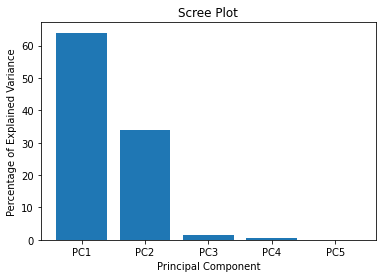

In [20]:
# Construct and create the Scree plot
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

         PC1        PC2        PC3       PC4           PC5
0 -17.511827 -20.486762  -0.638730  6.306715  2.489762e-14
1 -18.559246 -22.002771  -8.686206 -3.741648  4.432479e-14
2 -16.743831 -14.605739  10.508732 -2.697084  3.589013e-14
3  77.319216   3.804709  -0.249907 -0.009080 -2.063107e-13
4 -24.504312  53.290563  -0.933889  0.141098  1.033973e-13


KeyError: 5

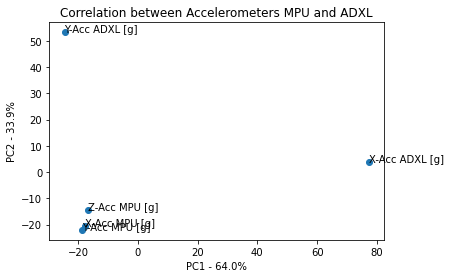

In [21]:
# Show correlation between input values depending on first two Principal components
pca_df1 = pd.DataFrame(pca_df,columns=labels)
print(pca_df1)
annotations=['X-Acc MPU [g]', 'Y-Acc MPU [g]', 'Z-Acc MPU [g]', 'X-Acc ADXL [g]', 'Y-Acc ADXL [g]', 'Z-Acc ADXL [g]']
        
plt.scatter(pca_df1.PC1, pca_df1.PC2)
plt.title('Correlation between Accelerometers MPU and ADXL')
plt.xlabel('PC1 - {0}%'.format(per_var[0]))
plt.ylabel('PC2 - {0}%'.format(per_var[1]))

for i, label in enumerate(annotations):
    plt.annotate(label, (pca_df1.PC1[i], pca_df1.PC2[i]))
 
plt.show()